# Introduction

<center><img src="https://i.imgur.com/9hLRsjZ.jpg" height=400></center>

This dataset was scraped from [nextspaceflight.com](https://nextspaceflight.com/launches/past/?page=1) and includes all the space missions since the beginning of Space Race between the USA and the Soviet Union in 1957!

### Install Package with Country Codes

In [31]:
%pip install iso3166

Note: you may need to restart the kernel to use updated packages.


### Upgrade Plotly

Run the cell below if you are working with Google Colab.

In [32]:
%pip install --upgrade plotly

Note: you may need to restart the kernel to use updated packages.


### Import Statements

In [33]:
import numpy as np
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

# These might be helpful:
from iso3166 import countries
from datetime import datetime, timedelta

### Notebook Presentation

In [34]:
import plotly.graph_objects as go
import plotly.io as pio

pd.options.display.float_format = '{:,.2f}'.format

# Muted 8-color palette — Simplified Science Publishing scientific figure palette
PALETTE = [
    '#59a89c',  # teal
    '#0b81a2',  # medium blue
    '#f0c571',  # warm gold
    '#e25759',  # muted red-coral
    '#7e4794',  # purple
    '#36b700',  # green
    '#57778d',  # steel blue
    '#c8c8c8',  # light gray
]

pio.templates['ssp_muted'] = go.layout.Template(
    layout=go.Layout(
        colorway=PALETTE,
        font=dict(family='Arial, sans-serif', size=13, color='#333333'),
        title_font=dict(family='Arial, sans-serif', size=17, color='#222222'),
        plot_bgcolor='#fafafa',
        paper_bgcolor='white',
        xaxis=dict(gridcolor='#ebebeb', linecolor='#cccccc', tickfont=dict(size=12)),
        yaxis=dict(gridcolor='#ebebeb', linecolor='#cccccc', tickfont=dict(size=12)),
    )
)
pio.templates.default = 'plotly_white+ssp_muted'

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 12,
    'axes.titlesize': 15,
    'axes.titleweight': 'bold',
    'axes.labelsize': 12,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.color': '#ebebeb',
    'axes.prop_cycle': plt.cycler(color=PALETTE),
})
sns.set_palette(PALETTE)

### Load the Data

In [35]:
df_data = pd.read_csv('mission_launches.csv', encoding='utf-8', encoding_errors='ignore')

# Preliminary Data Exploration

* What is the shape of `df_data`? 
* How many rows and columns does it have?
* What are the column names?
* Are there any NaN values or duplicates?

In [36]:
df_data_shape = df_data.shape
print(df_data_shape)

(4324, 9)


In [37]:
print(f"Rows: {df_data_shape[0]}\n"
      f"Columns: {df_data_shape[1]}")

Rows: 4324
Columns: 9


In [38]:
df_data.columns.tolist()

['Unnamed: 0.1',
 'Unnamed: 0',
 'Organisation',
 'Location',
 'Date',
 'Detail',
 'Rocket_Status',
 'Price',
 'Mission_Status']

In [39]:
df_data_nans = df_data.isnull().sum()
df_data_nans = df_data_nans[df_data_nans > 0]
df_data_duplicates = df_data.duplicated().sum()
print(f"NaN data:\n{df_data_nans.to_string()}")
print(f"Duplicates: {df_data_duplicates}")

NaN data:
Price    3360
Duplicates: 0


## Data Cleaning - Check for Missing Values and Duplicates

Consider removing columns containing junk data. 

In [40]:
df_data = df_data.drop(columns=['Unnamed: 0', 'Unnamed: 0.1'], errors='ignore')
df_data.head()

,Organisation,Location,Date,Detail,Rocket_Status,Price,Mission_Status
0,SpaceX,"LC-39A, Kennedy Space Center, Florida, USA","Fri Aug 07, 2020 05:12 UTC",Falcon 9 Block 5 | Starlink V1 L9 & BlackSky,StatusActive,50.0,Success
1,CASC,"Site 9401 (SLS-2), Jiuquan Satellite Launch Ce...","Thu Aug 06, 2020 04:01 UTC",Long March 2D | Gaofen-9 04 & Q-SAT,StatusActive,29.75,Success
2,SpaceX,"Pad A, Boca Chica, Texas, USA","Tue Aug 04, 2020 23:57 UTC",Starship Prototype | 150 Meter Hop,StatusActive,NaN,Success
3,Roscosmos,"Site 200/39, Baikonur Cosmodrome, Kazakhstan","Thu Jul 30, 2020 21:25 UTC",Proton-M/Briz-M | Ekspress-80 & Ekspress-103,StatusActive,65.0,Success
4,ULA,"SLC-41, Cape Canaveral AFS, Florida, USA","Thu Jul 30, 2020 11:50 UTC",Atlas V 541 | Perseverance,StatusActive,145.0,Success


In [41]:
df_data.columns

Index(['Organisation', 'Location', 'Date', 'Detail', 'Rocket_Status', 'Price',
       'Mission_Status'],
      dtype='str')

In [42]:
df_data_with_price = df_data.dropna(subset=['Price'])
print(df_data_with_price.shape)

(964, 7)


## Descriptive Statistics

In [43]:
df_data.describe(include='all')

,Organisation,Location,Date,Detail,Rocket_Status,Price,Mission_Status
count,4324,4324,4324,4324,4324,964,4324
unique,56,137,4319,4278,2,56,4
top,RVSN USSR,"Site 31/6, Baikonur Cosmodrome, Kazakhstan","Wed Nov 05, 2008 00:15 UTC",Cosmos-3MRB (65MRB) | BOR-5 Shuttle,StatusRetired,450.0,Success
freq,1777,235,2,6,3534,136,3879


# Number of Launches per Company

Create a chart that shows the number of space mission launches by organisation.

In [44]:
data_count = df_data['Organisation'].value_counts().sort_values()

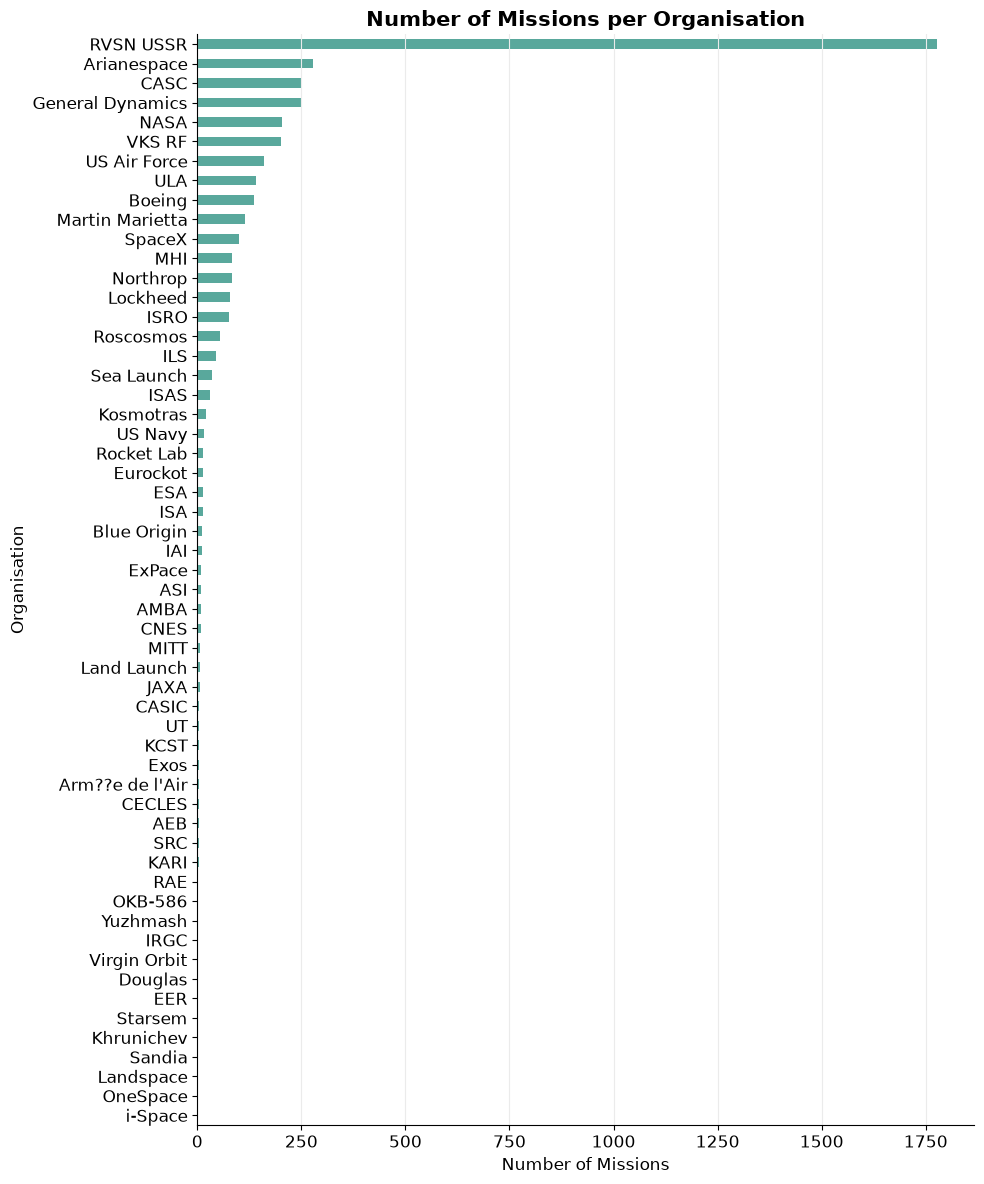

In [45]:
data_count.plot(
    kind='barh',
    figsize=(10, 12),
    edgecolor='none',
    linewidth=0
)

ax = plt.gca()
ax.yaxis.grid(False)
ax.xaxis.grid(True)

plt.title('Number of Missions per Organisation')
plt.xlabel('Number of Missions')
plt.tight_layout()
plt.show()

# Number of Active versus Retired Rockets

How many rockets are active compared to those that are decomissioned? 

In [46]:
mission_active_or_retired = df_data['Rocket_Status']. value_counts().sort_values()

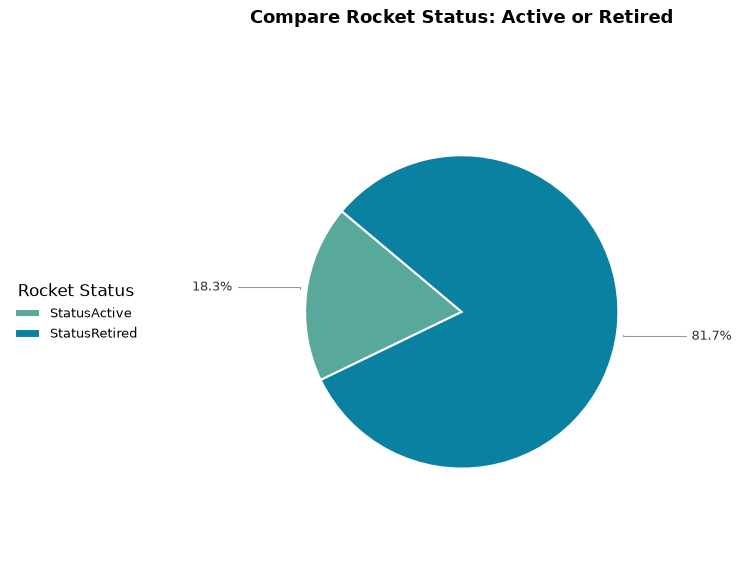

In [47]:
fig, ax = plt.subplots(figsize=(9, 6))

values = mission_active_or_retired.values
labels = mission_active_or_retired.index.tolist()
explode = [0.05 if v / values.sum() < 0.05 else 0 for v in values]

wedges, texts = ax.pie(
    values,
    labels=None,
    startangle=140,
    explode=explode,
    wedgeprops=dict(linewidth=1.5, edgecolor='white'),
    radius=0.75
)

for wedge, label, value in zip(wedges, labels, values):
    angle = (wedge.theta1 + wedge.theta2) / 2
    rad = np.radians(angle)
    pct = value / values.sum() * 100

    x_start = 0.78 * np.cos(rad)
    y_start = 0.78 * np.sin(rad)
    x_end = 0.95 * np.cos(rad)
    y_end = 0.95 * np.sin(rad)
    x_text = 1.1 if x_end > 0 else -1.1
    ha = 'left' if x_end > 0 else 'right'

    ax.annotate(
        f'{pct:.1f}%',
        xy=(x_start, y_start),
        xytext=(x_text, y_end),
        ha=ha, va='center',
        fontsize=9, color='#333333',
        arrowprops=dict(
            arrowstyle='-',
            color='#999999',
            lw=0.8,
            connectionstyle='angle,angleA=0,angleB=90,rad=0'
        )
    )

ax.legend(
    wedges,
    labels,
    title="Rocket Status",
    loc="center right",
    bbox_to_anchor=(-0.1, 0.5),
    frameon=False,
    fontsize=9
)

ax.set_title('Compare Rocket Status: Active or Retired',
             fontsize=13, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

# Distribution of Mission Status

How many missions were successful?
How many missions failed?

In [48]:
mission_success_or_failed = df_data['Mission_Status']. value_counts().sort_values()

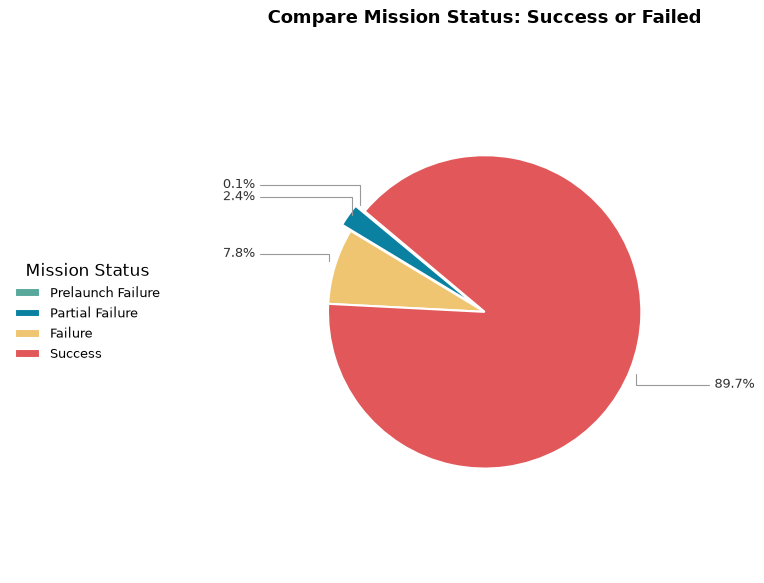

In [49]:
fig, ax = plt.subplots(figsize=(9, 6))

values = mission_success_or_failed.values
labels = mission_success_or_failed.index.tolist()
explode = [0.05 if v / values.sum() < 0.05 else 0 for v in values]

wedges, texts = ax.pie(
    values,
    labels=None,
    startangle=140,
    explode=explode,
    wedgeprops=dict(linewidth=1.5, edgecolor='white'),
    radius=0.75
)

for wedge, label, value in zip(wedges, labels, values):
    angle = (wedge.theta1 + wedge.theta2) / 2
    rad = np.radians(angle)
    pct = value / values.sum() * 100

    x_start = 0.78 * np.cos(rad)
    y_start = 0.78 * np.sin(rad)  # fixed — was 0.60, mismatched with x_start
    x_end = 0.95 * np.cos(rad)
    y_end = 0.95 * np.sin(rad)
    x_text = 1.1 if x_end > 0 else -1.1
    ha = 'left' if x_end > 0 else 'right'

    ax.annotate(
        f'{pct:.1f}%',
        xy=(x_start, y_start),
        xytext=(x_text, y_end),
        ha=ha, va='center',
        fontsize=9, color='#333333',
        arrowprops=dict(
            arrowstyle='-',
            color='#999999',
            lw=0.8,
            connectionstyle='angle,angleA=0,angleB=90,rad=0'
        )
    )

ax.legend(
    wedges,
    labels,
    title="Mission Status",
    loc="center right",
    bbox_to_anchor=(-0.1, 0.5),  
    frameon=False,
    fontsize=9
)

ax.set_title('Compare Mission Status: Success or Failed',
             fontsize=13, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

# How Expensive are the Launches? 

Create a histogram and visualise the distribution. The price column is given in USD millions (careful of missing values). 

In [50]:
df_data['Price'] = pd.to_numeric(df_data['Price'], errors='coerce')
df_data['Price'].max()

np.float64(450.0)

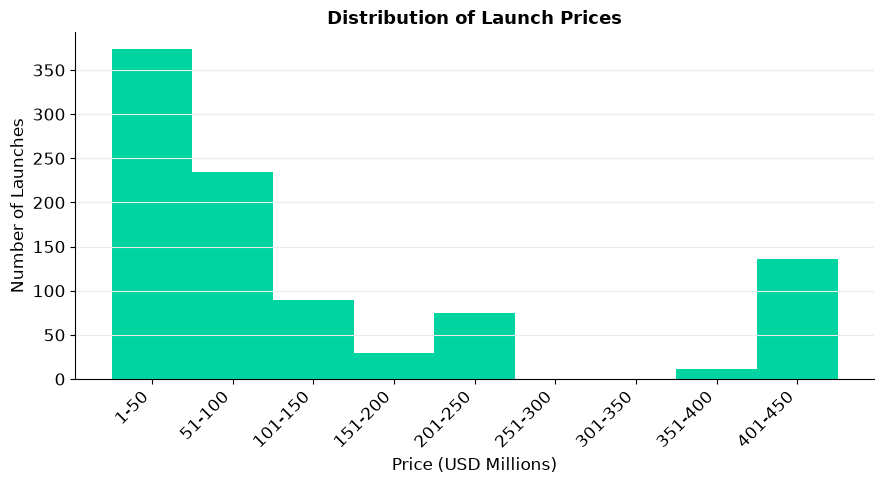

In [51]:
fig, ax = plt.subplots(figsize=(9, 5))

import numpy as np
bin_edges = list(range(0, 500, 50))  # [0, 50, 100, 150, ..., 450]

df_data_with_price['Price'] = pd.to_numeric(df_data_with_price['Price'], errors='coerce')

ax.hist(
    df_data_with_price['Price'],
    bins=bin_edges,
    color= '#00D4A0',
    edgecolor='none',
    linewidth=0
)

ax.set_title('Distribution of Launch Prices', fontsize=13, fontweight='bold')
ax.set_xlabel('Price (USD Millions)')
ax.set_ylabel('Number of Launches')
ax.yaxis.grid(True)
ax.xaxis.grid(False)

tick_positions = [(bin_edges[i] + bin_edges[i+1]) / 2 for i in range(len(bin_edges) - 1)]
tick_labels = [f"{bin_edges[i]+1}-{bin_edges[i+1]}" for i in range(len(bin_edges) - 1)]

ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, rotation=45, ha='right')

plt.tight_layout()
plt.show()

# Use a Choropleth Map to Show the Number of Launches by Country

* Create a choropleth map using [the plotly documentation](https://plotly.com/python/choropleth-maps/)
* Experiment with [plotly's available colours](https://plotly.com/python/builtin-colorscales/). I quite like the sequential colour `matter` on this map. 
* You'll need to extract a `country` feature as well as change the country names that no longer exist.

Wrangle the Country Names

You'll need to use a 3 letter country code for each country. You might have to change some country names.

* Russia is the Russian Federation
* New Mexico should be USA
* Yellow Sea refers to China
* Shahrud Missile Test Site should be Iran
* Pacific Missile Range Facility should be USA
* Barents Sea should be Russian Federation
* Gran Canaria should be USA


You can use the iso3166 package to convert the country names to Alpha3 format.

In [52]:
import pycountry

# Build the clean reference table — no manual edits needed here
countries = list(pycountry.countries)
data_country = pd.DataFrame([
    {"name": c.name, "alpha_2": c.alpha_2, "alpha_3": c.alpha_3}
    for c in countries
])

# Fix-up map for your launch data's non-standard country names
name_fixes = {
    "Russia": "Russian Federation",
    "New Mexico": "United States",
    "Yellow Sea": "China",
    "Shahrud Missile Test Site": "Iran",
    "Pacific Missile Range Facility": "United States",
    "Barents Sea": "Russian Federation",
    "Gran Canaria": "United States",
    "USA": "United States",
    "South Korea": "Korea, Republic of",
    "Iran": "Iran, Islamic Republic of",
    "North Korea": "Korea, Democratic People's Republic of",
}

df_data['Country'] = df_data['Location'].str.split(',').str[-1].str.strip()
df_data['Country'] = df_data['Country'].replace(name_fixes)

# Aggregate and convert to DataFrame
num_projects_by_country = df_data['Country'].value_counts().reset_index()
num_projects_by_country.columns = ['Country', 'Count']

num_projects_by_country['Country'] = num_projects_by_country['Country'].replace(name_fixes)

print(data_country[:3])
print(num_projects_by_country[:3])

# Merge in ISO-3 codes
data_country = pd.DataFrame(data_country)
num_projects_by_country = num_projects_by_country.merge(
    data_country[['name', 'alpha_3']],
    left_on='Country',
    right_on='name',
    how='left'
)

          name alpha_2 alpha_3
0        Aruba      AW     ABW
1  Afghanistan      AF     AFG
2       Angola      AO     AGO
              Country  Count
0  Russian Federation   1398
1       United States   1351
2          Kazakhstan    701


In [53]:
import re

country_data = pd.DataFrame(data_country, columns=['name', 'alpha_2', 'alpha_3'])
print(country_data)

result = country_data[country_data['name'] == 'Russian Federation']
print(result)

              name alpha_2 alpha_3
0            Aruba      AW     ABW
1      Afghanistan      AF     AFG
2           Angola      AO     AGO
3         Anguilla      AI     AIA
4    Åland Islands      AX     ALA
..             ...     ...     ...
244          Samoa      WS     WSM
245          Yemen      YE     YEM
246   South Africa      ZA     ZAF
247         Zambia      ZM     ZMB
248       Zimbabwe      ZW     ZWE

[249 rows x 3 columns]
                   name alpha_2 alpha_3
189  Russian Federation      RU     RUS


In [54]:
import plotly.graph_objects as go

df_data['Country'] = df_data['Location'].str.split(',').str[-1].str.strip()

# Merge in ISO-3 codes
data_country = pd.DataFrame(data_country)
num_projects_by_country = num_projects_by_country.merge(
    data_country[['name', 'alpha_3']],
    left_on='Country',
    right_on='name',
    how='left'
)

print(num_projects_by_country)

fig = go.Figure(data=go.Choropleth(
    locations = num_projects_by_country['alpha_3'],
    z = num_projects_by_country['Count'].astype(float),
    colorscale = "Viridis",
    marker_line_color = 'darkgray',
    marker_line_width = 0.5
))

fig.update_layout(
    title = {
        'text': 'Space Mission Projects in the World',
        'x' :0.5,
        'y' : 0.95,
        'xanchor': 'center',
        'yanchor': 'top'
    },
    height=400,
    margin={"r":0,"t":40,"l":0,"b":0}
    )

fig.show()

                                   Country  Count  \
0                       Russian Federation   1398   
1                            United States   1351   
2                               Kazakhstan    701   
3                                   France    303   
4                                    China    269   
5                                    Japan    126   
6                                    India     76   
7                            Pacific Ocean     36   
8                              New Zealand     13   
9                Iran, Islamic Republic of     13   
10                                  Israel     11   
11                                   Kenya      9   
12                               Australia      6   
13  Korea, Democratic People's Republic of      5   
14                      Korea, Republic of      3   
15                                  Brazil      3   
16               Iran, Islamic Republic of      1   

                                    name_x al

KeyError: 'alpha_3'

# Use a Choropleth Map to Show the Number of Failures by Country


In [ ]:
def calc_mission_failures():
    df_data['Country'] = df_data['Location'].str.split(',').str[-1].str.strip()
    failed = df_data[df_data['Mission_Status'] == 'Failure']
    num_failures_by_country = failed['Country'].value_counts().reset_index()
    num_failures_by_country.columns = ['Country', 'Failures']
    return num_failures_by_country

num_failures_by_country = calc_mission_failures()
print(num_failures_by_country[:3])

      Country  Failures
0         USA       127
1  Kazakhstan        72
2      Russia        62


In [ ]:
import pandas as pd
import pycountry
import plotly.graph_objects as go

# Fix-up map for the launch data's non-standard country/location names
name_fixes = {
    "Russia": "Russian Federation",
    "New Mexico": "United States",
    "Yellow Sea": "China",
    "Shahrud Missile Test Site": "Iran",
    "Pacific Missile Range Facility": "United States",
    "Barents Sea": "Russian Federation",
    "Gran Canaria": "United States",
    "USA": "United States",
    "South Korea": "Korea, Republic of",
    "Iran": "Iran, Islamic Republic of",
    "North Korea": "Korea, Democratic People's Republic of",
}

# Clean ISO reference table — built once, never touched again
data_country = pd.DataFrame([
    {"name": c.name, "alpha_2": c.alpha_2, "alpha_3": c.alpha_3}
    for c in pycountry.countries
])

def get_clean_country_series(df):
    """Derive a clean, name_fixes-applied Country column from Location."""
    return df['Location'].str.split(',').str[-1].str.strip().replace(name_fixes)

def calc_mission_failures(df):
    """Return failure counts per country, with ISO alpha_3 codes merged in."""
    df = df.copy()
    df['Country'] = get_clean_country_series(df)

    failed = df[df['Mission_Status'] == 'Failure']
    counts = (
        failed['Country']
        .value_counts()
        .reset_index()
        .rename(columns={'count': 'Failures', 'index': 'Country'})
    )
    # pandas >=2.0 names the count column 'count' by default; the rename above
    # covers both old and new pandas behaviour for the count column name.
    counts.columns = ['Country', 'Failures']

    return counts.merge(
        data_country[['name', 'alpha_3']],
        left_on='Country',
        right_on='name',
        how='left'
    )

num_failures_by_country = calc_mission_failures(df_data)
print(num_failures_by_country)

fig = go.Figure(data=go.Choropleth(
    locations=num_failures_by_country['alpha_3'],
    z=num_failures_by_country['Failures'].astype(float),
    colorscale="YlOrRd",
    marker_line_color='darkgray',
    marker_line_width=0.5
))
fig.update_layout(
    title={
        'text': 'Failed Space Mission Projects in the World',
        'x': 0.5,
        'y': 0.95,
        'xanchor': 'center',
        'yanchor': 'top'
    },
    height=400,
    margin={"r": 0, "t": 40, "l": 0, "b": 0}
)
fig.show()

                                   Country  Failures  \
0                            United States       129   
1                               Kazakhstan        72   
2                       Russian Federation        63   
3                                    China        19   
4                                   France        13   
5                                    Japan        10   
6                Iran, Islamic Republic of         8   
7                                    India         8   
8                            Pacific Ocean         3   
9   Korea, Democratic People's Republic of         3   
10                               Australia         3   
11                             New Zealand         2   
12                      Korea, Republic of         2   
13                                  Israel         2   
14                                  Brazil         2   

                                      name alpha_3  
0                            United States     USA

# Create a Plotly Sunburst Chart of the countries, organisations, and mission status. 

In [ ]:
import plotly.express as px
import pandas as pd
import pycountry

# Fix-up map for the launch data's non-standard country/location names
name_fixes = {
    "Russia": "Russian Federation",
    "New Mexico": "United States",
    "Yellow Sea": "China",
    "Shahrud Missile Test Site": "Iran",
    "Pacific Missile Range Facility": "United States",
    "Barents Sea": "Russian Federation",
    "Gran Canaria": "United States",
    "USA": "United States",
    "South Korea": "Korea, Republic of",
    "Iran": "Iran, Islamic Republic of",
    "North Korea": "Korea, Democratic People's Republic of",
}

# Clean ISO reference table — built once, never touched again
data_country = pd.DataFrame([
    {"name": c.name, "alpha_2": c.alpha_2, "alpha_3": c.alpha_3}
    for c in pycountry.countries
])

def get_clean_country_series(df):
    """Derive a clean, name_fixes-applied Country column from Location."""
    return df['Location'].str.split(',').str[-1].str.strip().replace(name_fixes)

def missions_with_details(df):
    """
    Returns:
        df_with_country: original df plus a clean 'Country' column
        hierarchy_counts: Country -> Rocket_Status -> Mission_Status counts,
                           with alpha_3 merged in, ready for px.sunburst
    """
    df = df.copy()
    df['Country'] = get_clean_country_series(df)

    hierarchy_counts = (
        df.groupby(['Country', 'Rocket_Status', 'Mission_Status'])
        .size()
        .reset_index(name='Count')
    )

    hierarchy_counts = hierarchy_counts.merge(
        data_country[['name', 'alpha_3']],
        left_on='Country',
        right_on='name',
        how='left'
    )

    return df, hierarchy_counts

df_data, hierarchy_counts = missions_with_details(df_data)

fig = px.sunburst(
    hierarchy_counts,
    path=['Country', 'Rocket_Status', 'Mission_Status'],
    values='Count',
    title='Space Missions by Country, Rocket Status, and Mission Status'
)
fig.show()

# Analyse the Total Amount of Money Spent by Organisation on Space Missions

In [ ]:
import pandas as pd
import plotly.express as px

def get_organisation_spend(df):
    """
    Returns total spend per organisation, sorted ascending by amount.
    Rows with missing/unparseable Price are excluded from the total.
    """
    df = df.copy()

    # Price often arrives as a string with commas/whitespace; coerce to numeric
    df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

    spend = (
        df.dropna(subset=['Price'])
        .groupby('Organisation')['Price']
        .sum()
        .reset_index()
        .rename(columns={'Price': 'Total_Spend'})
        .sort_values('Total_Spend', ascending=False)
    )

    return spend

org_spend = get_organisation_spend(df_data)
print(org_spend)

fig = px.bar(
    org_spend,
    x='Organisation',
    y='Total_Spend',
    text='Total_Spend',
    title='Total Amount Spent by Organisation',
    labels={'Total_Spend': 'Total Spend ($ millions)', 'Organisation': 'Organisation'}
)
fig.update_layout(
    xaxis_tickangle=-45,
    yaxis_tickformat=','
    )
fig.show()

       Organisation  Total_Spend
14             NASA    61,200.00
0       Arianespace    16,345.00
20              ULA    14,798.00
2              CASC     6,340.26
19           SpaceX     5,444.00
15         Northrop     3,930.00
12              MHI     3,532.50
8              ISRO     2,177.00
21     US Air Force     1,550.92
22           VKS RF     1,548.90
7               ILS     1,320.00
1            Boeing     1,241.00
17        Roscosmos     1,187.50
13  Martin Marietta       721.40
10        Kosmotras       638.00
5          Eurockot       543.40
11         Lockheed       280.00
9              JAXA       168.00
16       Rocket Lab        97.50
4               ESA        37.00
6            ExPace        28.30
3               EER        20.00
18           Sandia        15.00
23     Virgin Orbit        12.00


# Analyse the Amount of Money Spent by Organisation per Launch

In [ ]:
import pandas as pd
import plotly.express as px

def get_organisation_spend_per_launch(df):
    """
    Returns total spend, launch count, and average spend per launch,
    for each organisation. Only launches with a known Price are counted
    toward both the total and the launch count, so the average is a true
    'cost per priced launch', not diluted by unpriced missions.
    """
    df = df.copy()
    df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

    priced = df.dropna(subset=['Price'])

    summary = (
        priced.groupby('Organisation')['Price']
        .agg(Total_Spend='sum', Priced_Launches='count', Avg_Spend_Per_Launch='mean')
        .reset_index()
        .sort_values('Avg_Spend_Per_Launch', ascending=False)
    )

    return summary

org_summary = get_organisation_spend_per_launch(df_data)
print(org_summary)

fig = px.bar(
    org_summary,
    x='Organisation',
    y='Avg_Spend_Per_Launch',
    text='Avg_Spend_Per_Launch',
    title='Average Amount Spent per Launch by Organisation',
    labels={'Avg_Spend_Per_Launch': 'Avg Spend per Launch ($ millions)', 'Organisation': 'Organisation'}
)
fig.update_traces(texttemplate='%{text:,.1f}', textposition='outside')
fig.update_layout(xaxis_tickangle=-45, yaxis_tickformat=',')
fig.show()

       Organisation  Total_Spend  Priced_Launches  Avg_Spend_Per_Launch
14             NASA    61,200.00              136                450.00
1            Boeing     1,241.00                7                177.29
0       Arianespace    16,345.00               96                170.26
20              ULA    14,798.00               98                151.00
7               ILS     1,320.00               13                101.54
12              MHI     3,532.50               37                 95.47
13  Martin Marietta       721.40                9                 80.16
21     US Air Force     1,550.92               26                 59.65
9              JAXA       168.00                3                 56.00
19           SpaceX     5,444.00               99                 54.99
17        Roscosmos     1,187.50               23                 51.63
15         Northrop     3,930.00               83                 47.35
22           VKS RF     1,548.90               33               

# Chart the Number of Launches per Year

In [ ]:
import pandas as pd
import plotly.express as px

def get_launches_per_year(df):
    df = df.copy()
    df['Year'] = pd.to_datetime(df['Date'], errors='coerce').dt.year

    launches_per_year = (
        df.dropna(subset=['Year'])
        .groupby('Year')
        .size()
        .reset_index(name='Total_Launches')
        .sort_values('Year')
    )

    return launches_per_year

launches_per_year = get_launches_per_year(df_data)
print(launches_per_year)

fig = px.line(
    launches_per_year,
    x='Year',
    y='Total_Launches',
    title='Total Launches per Year',
    markers=True,
)
fig.update_layout(yaxis_tickformat=',')
fig.show()

       Year  Total_Launches
0  1,957.00               3
1  1,958.00              22
2  1,959.00              20
3  1,960.00              38
4  1,961.00              52
..      ...             ...
59 2,016.00              88
60 2,017.00              90
61 2,018.00             117
62 2,019.00             107
63 2,020.00              63

[64 rows x 2 columns]


# Chart the Number of Launches Month-on-Month until the Present

Which month has seen the highest number of launches in all time? Superimpose a rolling average on the month on month time series chart. 

# Launches per Month: Which months are most popular and least popular for launches?

Some months have better weather than others. Which time of year seems to be best for space missions?

In [58]:
import pandas as pd
import plotly.express as px

def get_launches_by_month_and_status(df):
    df = df.copy()
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    df = df.dropna(subset=['Date'])

    df['Month'] = df['Date'].dt.month
    df['Month_Name'] = df['Date'].dt.strftime('%B')

    launches = (
        df.groupby(['Month', 'Month_Name', 'Mission_Status'])
        .size()
        .reset_index(name='Total_Launches')
        .sort_values('Month')
    )

    return launches

launches_by_month_status = get_launches_by_month_and_status(df_data)
print(launches_by_month_status['Mission_Status'].unique())  # confirm actual category names

month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

status_order = ['Success', 'Partial Failure', 'Failure']  # bottom -> top

color_map = {
    'Success': '#2CA02C',          # green
    'Partial Failure': '#FF7F0E',  # orange
    'Failure': '#D62728',          # red
}

fig = px.bar(
    launches_by_month_status,
    x='Month_Name',
    y='Total_Launches',
    color='Mission_Status',
    category_orders={'Month_Name': month_order, 'Mission_Status': status_order},
    color_discrete_map=color_map,
    title='Launches by Calendar Month, Stacked by Mission Outcome',
    labels={'Total_Launches': 'Total Launches', 'Month_Name': 'Month', 'Mission_Status': 'Outcome'}
)
fig.update_layout(yaxis_tickformat=',', barmode='stack')
fig.show()

<StringArray>
['Failure', 'Partial Failure', 'Success', 'Prelaunch Failure']
Length: 4, dtype: str


# How has the Launch Price varied Over Time? 

Create a line chart that shows the average price of rocket launches over time. 

In [59]:
import pandas as pd
import plotly.express as px

def get_avg_price_over_time(df):
    """
    Returns average launch price per year. Only launches with a known,
    parseable Price contribute to the average for that year.
    """
    df = df.copy()
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

    df = df.dropna(subset=['Date', 'Price'])
    df['Year'] = df['Date'].dt.year

    avg_price_per_year = (
        df.groupby('Year')['Price']
        .mean()
        .reset_index(name='Avg_Price')
        .sort_values('Year')
    )

    return avg_price_per_year

avg_price_per_year = get_avg_price_over_time(df_data)
print(avg_price_per_year)

fig = px.line(
    avg_price_per_year,
    x='Year',
    y='Avg_Price',
    title='Average Launch Mission Price Over Time',
    labels={'Avg_Price': 'Average Price ($ millions)', 'Year': 'Year'},
    markers=True,
)
fig.update_layout(yaxis_tickformat=',')
fig.show()

    Year  Avg_Price
0   1964      63.23
1   1965      63.23
2   1966      59.00
3   1967      59.00
4   1968      59.00
5   1969      59.00
6   1981     450.00
7   1982     345.20
8   1983     366.16
9   1984     380.13
10  1985     408.08
11  1986     310.27
12  1987      30.80
13  1988     241.45
14  1989     380.83
15  1990     289.15
16  1991     391.43
17  1992     319.35
18  1993     276.73
19  1994     221.51
20  1995     325.00
21  1996     243.20
22  1997     221.74
23  1998     152.12
24  1999     136.17
25  2000     173.12
26  2001     290.70
27  2002     195.37
28  2003      80.51
29  2004      92.74
30  2005      95.79
31  2006     138.61
32  2007     125.70
33  2008     129.75
34  2009     180.29
35  2010     148.40
36  2011     146.60
37  2012     126.10
38  2013      90.55
39  2014     102.55
40  2015      95.95
41  2016      79.46
42  2017      69.49
43  2018      64.75
44  2019      59.61
45  2020      56.65


# Chart the Number of Launches over Time by the Top 10 Organisations. 

How has the dominance of launches changed over time between the different players? 

In [60]:
import pandas as pd
import plotly.express as px

def get_top10_org_launches_by_year(df):
    """
    Returns yearly launch counts for the 10 organisations with the most
    total launches across the entire dataset. Only those 10 orgs are
    included; everyone else is excluded from the result.
    """
    df = df.copy()
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    df = df.dropna(subset=['Date'])
    df['Year'] = df['Date'].dt.year

    top10_orgs = (
        df['Organisation']
        .value_counts()
        .head(10)
        .index
    )

    filtered = df[df['Organisation'].isin(top10_orgs)]

    launches_by_year_org = (
        filtered.groupby(['Year', 'Organisation'])
        .size()
        .reset_index(name='Total_Launches')
        .sort_values('Year')
    )

    return launches_by_year_org, list(top10_orgs)

launches_by_year_org, top10_orgs = get_top10_org_launches_by_year(df_data)
print(top10_orgs)
print(launches_by_year_org)

fig = px.line(
    launches_by_year_org,
    x='Year',
    y='Total_Launches',
    color='Organisation',
    category_orders={'Organisation': top10_orgs},  # legend order = rank order
    title='Launches per Year — Top 10 Organisations',
    labels={'Total_Launches': 'Total Launches', 'Year': 'Year'},
    markers=True,
)
fig.update_layout(yaxis_tickformat=',')
fig.show()

['RVSN USSR', 'Arianespace', 'CASC', 'General Dynamics', 'NASA', 'VKS RF', 'US Air Force', 'ULA', 'Boeing', 'Martin Marietta']
     Year      Organisation  Total_Launches
0    1957         RVSN USSR               2
1    1958              NASA               2
2    1958         RVSN USSR               5
3    1958      US Air Force               2
4    1959  General Dynamics               1
..    ...               ...             ...
317  2019            VKS RF               8
318  2020       Arianespace               4
319  2020              CASC              19
320  2020               ULA               4
321  2020            VKS RF               3

[322 rows x 3 columns]


# Cold War Space Race: USA vs USSR

The cold war lasted from the start of the dataset up until 1991. 

In [62]:
import pandas as pd
import plotly.express as px


name_fixes = {
    "Russia": "Russian Federation",
    "New Mexico": "United States",
    "Yellow Sea": "China",
    "Shahrud Missile Test Site": "Iran",
    "Pacific Missile Range Facility": "United States",
    "Barents Sea": "Russian Federation",
    "Gran Canaria": "United States",
    "USA": "United States",
    "South Korea": "Korea, Republic of",
    "Iran": "Iran, Islamic Republic of",
    "North Korea": "Korea, Democratic People's Republic of",
}

def get_clean_country_series(df):
    """Derive a clean, name_fixes-applied Country column from Location."""
    return df['Location'].str.split(',').str[-1].str.strip().replace(name_fixes)

def get_cold_war_us_ussr_launches(df):
    """
    Returns yearly launch counts for the USA and USSR/Russia,
    restricted to the Cold War period (1947-1991).
    """
    df = df.copy()
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    df = df.dropna(subset=['Date'])
    df['Year'] = df['Date'].dt.year

    df['Country'] = get_clean_country_series(df)

    # Restrict to the Cold War window
    cold_war = df[(df['Year'] >= 1947) & (df['Year'] <= 1991)]

    # name_fixes maps both pre- and post-1991 launches to 'Russian Federation',
    # which is the only sensible single label for USSR-era launches here since
    # the dataset has no separate 'USSR' country value — relabel for clarity
    cold_war = cold_war.copy()
    cold_war['Country'] = cold_war['Country'].replace({'Russian Federation': 'USSR'})

    us_ussr = cold_war[cold_war['Country'].isin(['United States', 'USSR'])]

    launches_by_year_country = (
        us_ussr.groupby(['Year', 'Country'])
        .size()
        .reset_index(name='Total_Launches')
        .sort_values('Year')
    )

    return launches_by_year_country

cold_war_launches = get_cold_war_us_ussr_launches(df_data)
print(cold_war_launches)

fig = px.line(
    cold_war_launches,
    x='Year',
    y='Total_Launches',
    color='Country',
    color_discrete_map={'United States': '#1f77b4', 'USSR': '#d62728'},
    title='The Space Race: USA vs USSR Launches (1947–1991)',
    labels={'Total_Launches': 'Total Launches', 'Year': 'Year'},
    markers=True,
)
fig.update_layout(yaxis_tickformat=',')
fig.show()

    Year        Country  Total_Launches
0   1957  United States               1
1   1958  United States              17
2   1959  United States              16
3   1960  United States              30
4   1961           USSR               2
..   ...            ...             ...
61  1989  United States              16
62  1990           USSR              28
63  1990  United States              26
64  1991           USSR              24
65  1991  United States              18

[66 rows x 3 columns]


## Create a Plotly Pie Chart comparing the total number of launches of the USSR and the USA

Hint: Remember to include former Soviet Republics like Kazakhstan when analysing the total number of launches. 

In [63]:
import pandas as pd
import plotly.express as px

name_fixes = {
    "Russia": "Russian Federation",
    "New Mexico": "United States",
    "Yellow Sea": "China",
    "Shahrud Missile Test Site": "Iran",
    "Pacific Missile Range Facility": "United States",
    "Barents Sea": "Russian Federation",
    "Gran Canaria": "United States",
    "USA": "United States",
    "South Korea": "Korea, Republic of",
    "Iran": "Iran, Islamic Republic of",
    "North Korea": "Korea, Democratic People's Republic of",
    "Kazakhstan": "USSR",  # Baikonur Cosmodrome — Soviet-era launches
}

def get_clean_country_series(df):
    return df['Location'].str.split(',').str[-1].str.strip().replace(name_fixes)

def get_us_ussr_pie_data(df):
    """
    Total launches for USA vs USSR, with all historically Soviet
    launch sites (Russia, Kazakhstan) folded into a single 'USSR' label.
    """
    df = df.copy()
    df['Country'] = get_clean_country_series(df)

    # Both pre- and post-1991 Russian Federation launches map to USSR for
    # this comparison, since the dataset has no separate USSR/Russia split
    df['Country'] = df['Country'].replace({'Russian Federation': 'USSR'})

    us_ussr = df[df['Country'].isin(['United States', 'USSR'])]

    pie_data = (
        us_ussr['Country']
        .value_counts()
        .reset_index()
    )
    pie_data.columns = ['Country', 'Total_Launches']

    return pie_data

pie_data = get_us_ussr_pie_data(df_data)
print(pie_data)

fig = px.pie(
    pie_data,
    names='Country',
    values='Total_Launches',
    title='Total Launches: USA vs USSR',
    color='Country',
    color_discrete_map={'United States': '#1f77b4', 'USSR': '#d62728'},
)
fig.update_traces(textinfo='label+percent+value')
fig.show()

         Country  Total_Launches
0           USSR            2099
1  United States            1351


## Create a Chart that Shows the Total Number of Launches Year-On-Year by the Two Superpowers

In [64]:
import pandas as pd
import plotly.express as px

name_fixes = {
    "Russia": "Russian Federation",
    "New Mexico": "United States",
    "Yellow Sea": "China",
    "Shahrud Missile Test Site": "Iran",
    "Pacific Missile Range Facility": "United States",
    "Barents Sea": "Russian Federation",
    "Gran Canaria": "United States",
    "USA": "United States",
    "South Korea": "Korea, Republic of",
    "Iran": "Iran, Islamic Republic of",
    "North Korea": "Korea, Democratic People's Republic of",
    "Kazakhstan": "USSR",  # Baikonur Cosmodrome — Soviet-era launches
}

def get_clean_country_series(df):
    return df['Location'].str.split(',').str[-1].str.strip().replace(name_fixes)

def get_us_ussr_year_on_year(df):
    """
    Yearly launch counts for the USA and USSR/Russia across the full
    dataset range, with all historically Soviet/Russian launch sites
    (Russia, Kazakhstan) folded into a single 'USSR' label.
    """
    df = df.copy()
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    df = df.dropna(subset=['Date'])
    df['Year'] = df['Date'].dt.year

    df['Country'] = get_clean_country_series(df)
    df['Country'] = df['Country'].replace({'Russian Federation': 'USSR'})

    us_ussr = df[df['Country'].isin(['United States', 'USSR'])]

    launches_by_year = (
        us_ussr.groupby(['Year', 'Country'])
        .size()
        .reset_index(name='Total_Launches')
        .sort_values('Year')
    )

    return launches_by_year

launches_by_year = get_us_ussr_year_on_year(df_data)
print(launches_by_year)

fig = px.line(
    launches_by_year,
    x='Year',
    y='Total_Launches',
    color='Country',
    color_discrete_map={'United States': '#1f77b4', 'USSR': '#d62728'},
    title='Total Launches Year-on-Year: USA vs USSR',
    labels={'Total_Launches': 'Total Launches', 'Year': 'Year'},
    markers=True,
)
fig.update_layout(yaxis_tickformat=',')
fig.show()

     Year        Country  Total_Launches
0    1957           USSR               2
1    1957  United States               1
2    1958           USSR               5
3    1958  United States              17
4    1959           USSR               4
..    ...            ...             ...
123  2018  United States              34
124  2019           USSR              22
125  2019  United States              27
126  2020           USSR               9
127  2020  United States              21

[128 rows x 3 columns]


## Chart the Total Number of Mission Failures Year on Year.

In [65]:
import pandas as pd
import plotly.express as px

def get_failures_year_on_year(df):
    """
    Total number of 'Failure' missions per year, across all countries
    and organisations combined.
    """
    df = df.copy()
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    df = df.dropna(subset=['Date'])
    df['Year'] = df['Date'].dt.year

    failures = df[df['Mission_Status'] == 'Failure']

    failures_by_year = (
        failures.groupby('Year')
        .size()
        .reset_index(name='Total_Failures')
        .sort_values('Year')
    )

    return failures_by_year

failures_by_year = get_failures_year_on_year(df_data)
print(failures_by_year)

fig = px.line(
    failures_by_year,
    x='Year',
    y='Total_Failures',
    title='Total Number of Failures Year-on-Year',
    labels={'Total_Failures': 'Total Failures', 'Year': 'Year'},
    markers=True,
)
fig.update_layout(yaxis_tickformat=',')
fig.show()

    Year  Total_Failures
0   1957               1
1   1958              14
2   1959               9
3   1960              19
4   1961              17
..   ...             ...
58  2016               2
59  2017               5
60  2018               2
61  2019               5
62  2020               6

[63 rows x 2 columns]


## Chart the Percentage of Failures over Time

Did failures go up or down over time? Did the countries get better at minimising risk and improving their chances of success over time? 

In [66]:
import pandas as pd
import plotly.express as px

def get_failure_rate_year_on_year(df):
    """
    Failure rate (%) per year = Failures / Total Launches that year * 100,
    across all countries and organisations combined.
    """
    df = df.copy()
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    df = df.dropna(subset=['Date'])
    df['Year'] = df['Date'].dt.year

    yearly = (
        df.groupby('Year')
        .agg(
            Total_Launches=('Mission_Status', 'size'),
            Total_Failures=('Mission_Status', lambda s: (s == 'Failure').sum())
        )
        .reset_index()
    )

    yearly['Failure_Rate_Pct'] = (yearly['Total_Failures'] / yearly['Total_Launches']) * 100

    return yearly.sort_values('Year')

failure_rate_by_year = get_failure_rate_year_on_year(df_data)
print(failure_rate_by_year)

fig = px.line(
    failure_rate_by_year,
    x='Year',
    y='Failure_Rate_Pct',
    title='Failure Rate (%) Year-on-Year',
    labels={'Failure_Rate_Pct': 'Failure Rate (%)', 'Year': 'Year'},
    markers=True,
)
fig.update_layout(yaxis_tickformat='.1f', yaxis_ticksuffix='%')
fig.show()

    Year  Total_Launches  Total_Failures  Failure_Rate_Pct
0   1957               3               1             33.33
1   1958              22              14             63.64
2   1959              20               9             45.00
3   1960              38              19             50.00
4   1961              52              17             32.69
..   ...             ...             ...               ...
59  2016              88               2              2.27
60  2017              90               5              5.56
61  2018             117               2              1.71
62  2019             107               5              4.67
63  2020              63               6              9.52

[64 rows x 4 columns]


# For Every Year Show which Country was in the Lead in terms of Total Number of Launches up to and including including 2020)

Do the results change if we only look at the number of successful launches? 

In [67]:
import pandas as pd
import plotly.express as px

name_fixes = {
    "Russia": "Russian Federation",
    "New Mexico": "United States",
    "Yellow Sea": "China",
    "Shahrud Missile Test Site": "Iran",
    "Pacific Missile Range Facility": "United States",
    "Barents Sea": "Russian Federation",
    "Gran Canaria": "United States",
    "USA": "United States",
    "South Korea": "Korea, Republic of",
    "Iran": "Iran, Islamic Republic of",
    "North Korea": "Korea, Democratic People's Republic of",
    "Kazakhstan": "Russian Federation",  # Baikonur Cosmodrome
}

def get_clean_country_series(df):
    return df['Location'].str.split(',').str[-1].str.strip().replace(name_fixes)

def get_leader_by_year(df, successful_only=False):
    """
    For every year up to and including 2020, identifies which country
    had the highest CUMULATIVE launch count (running total since the
    dataset's earliest year), optionally restricted to successful launches.
    """
    df = df.copy()
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    df = df.dropna(subset=['Date'])
    df['Year'] = df['Date'].dt.year
    df['Country'] = get_clean_country_series(df)

    df = df[df['Year'] <= 2020]
    if successful_only:
        df = df[df['Mission_Status'] == 'Success']

    # Launches per country per year
    yearly_counts = (
        df.groupby(['Year', 'Country'])
        .size()
        .reset_index(name='Launches')
    )

    # Pivot so each country is a column, fill years/countries with no
    # launches that year as 0, then cumulatively sum down each column
    pivot = yearly_counts.pivot(index='Year', columns='Country', values='Launches').fillna(0)
    pivot = pivot.sort_index()
    cumulative = pivot.cumsum()

    # For each year, find the country with the highest cumulative total
    leader = cumulative.idxmax(axis=1).reset_index()
    leader.columns = ['Year', 'Leading_Country']
    leader['Leading_Cumulative_Launches'] = cumulative.max(axis=1).values

    return leader

leader_all = get_leader_by_year(df_data, successful_only=False)
leader_success = get_leader_by_year(df_data, successful_only=True)

print("All launches:")
print(leader_all)
print("\nSuccessful launches only:")
print(leader_success)

# Compare whether the leader differs in any year
comparison = leader_all.merge(
    leader_success, on='Year', suffixes=('_All', '_Success')
)
comparison['Differs'] = comparison['Leading_Country_All'] != comparison['Leading_Country_Success']
print("\nYears where the leader differs:")
print(comparison[comparison['Differs']])

All launches:
    Year     Leading_Country  Leading_Cumulative_Launches
0   1957  Russian Federation                         2.00
1   1958       United States                        18.00
2   1959       United States                        34.00
3   1960       United States                        64.00
4   1961       United States                       107.00
..   ...                 ...                          ...
59  2016  Russian Federation                     1,966.00
60  2017  Russian Federation                     1,985.00
61  2018  Russian Federation                     2,002.00
62  2019  Russian Federation                     2,024.00
63  2020  Russian Federation                     2,033.00

[64 rows x 3 columns]

Successful launches only:
    Year     Leading_Country  Leading_Cumulative_Launches
0   1957  Russian Federation                         2.00
1   1958       United States                         5.00
2   1959       United States                        11.00
3   1960

In [68]:
def get_cumulative_chart_data(df, successful_only=False):
    df = df.copy()
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    df = df.dropna(subset=['Date'])
    df['Year'] = df['Date'].dt.year
    df['Country'] = get_clean_country_series(df)

    df = df[df['Year'] <= 2020]
    if successful_only:
        df = df[df['Mission_Status'] == 'Success']

    yearly_counts = df.groupby(['Year', 'Country']).size().reset_index(name='Launches')
    pivot = yearly_counts.pivot(index='Year', columns='Country', values='Launches').fillna(0).sort_index()
    cumulative = pivot.cumsum().reset_index()

    melted = cumulative.melt(id_vars='Year', var_name='Country', value_name='Cumulative_Launches')
    return melted

# Restrict to the top few countries by final cumulative total, so the chart isn't
# cluttered with dozens of low-volume countries
chart_data = get_cumulative_chart_data(df_data, successful_only=False)
top_countries = (
    chart_data.groupby('Country')['Cumulative_Launches'].max()
    .nlargest(6)
    .index
)
chart_data_top = chart_data[chart_data['Country'].isin(top_countries)]

fig = px.line(
    chart_data_top,
    x='Year',
    y='Cumulative_Launches',
    color='Country',
    title='Cumulative Launches by Country, Up to and Including 2020',
    labels={'Cumulative_Launches': 'Cumulative Total Launches'},
    markers=True,
)
fig.update_layout(yaxis_tickformat=',')
fig.show()

# Create a Year-on-Year Chart Showing the Organisation Doing the Most Number of Launches

Which organisation was dominant in the 1970s and 1980s? Which organisation was dominant in 2018, 2019 and 2020? 

In [69]:
import pandas as pd
import plotly.express as px

def get_top_org_by_year(df):
    """
    For every year, finds the organisation with the most launches that
    specific year (not cumulative — a fresh comparison each year).
    """
    df = df.copy()
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    df = df.dropna(subset=['Date'])
    df['Year'] = df['Date'].dt.year

    yearly_counts = (
        df.groupby(['Year', 'Organisation'])
        .size()
        .reset_index(name='Launches')
    )

    # For each year, keep only the row with the highest launch count
    idx = yearly_counts.groupby('Year')['Launches'].idxmax()
    top_org_by_year = yearly_counts.loc[idx].sort_values('Year').reset_index(drop=True)

    return top_org_by_year, yearly_counts

top_org_by_year, yearly_counts = get_top_org_by_year(df_data)
print(top_org_by_year)

fig = px.bar(
    top_org_by_year,
    x='Year',
    y='Launches',
    color='Organisation',
    title='Organisation with the Most Launches per Year',
    labels={'Launches': 'Launches that Year'},
)
fig.update_layout(yaxis_tickformat=',')
fig.show()

    Year  Organisation  Launches
0   1957     RVSN USSR         2
1   1958          AMBA         7
2   1959  US Air Force        10
3   1960  US Air Force        21
4   1961  US Air Force        23
..   ...           ...       ...
59  2016          CASC        22
60  2017        SpaceX        18
61  2018          CASC        37
62  2019          CASC        27
63  2020          CASC        19

[64 rows x 3 columns]


In [ ]:

import numpy as np
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.io as pio
from iso3166 import countries
from datetime import datetime, timedelta

pd.options.display.float_format = '{:,.2f}'.format

PALETTE = [
    '#59a89c',
    '#0b81a2',
    '#f0c571',
    '#e25759',
    '#7e4794',
    '#36b700',
    '#57778d',
    '#c8c8c8',
]

pio.templates['ssp_muted'] = go.layout.Template(
    layout=go.Layout(
        colorway=PALETTE,
        font=dict(family='Arial, sans-serif', size=13, color='#333333'),
        title_font=dict(family='Arial, sans-serif', size=17, color='#222222', weight=500),
        plot_bgcolor='#fafafa',
        paper_bgcolor='white',
        xaxis=dict(gridcolor='#ebebeb', linecolor='#cccccc', tickfont=dict(size=12)),
        yaxis=dict(gridcolor='#ebebeb', linecolor='#cccccc', tickfont=dict(size=12)),
        legend=dict(
            x=0.01, y=0.99,
            xanchor='left', yanchor='top',
            bgcolor='rgba(255,255,255,0.85)',
            bordercolor='#cccccc', borderwidth=1,
        ),
    )
)
pio.templates.default = 'plotly_white+ssp_muted'

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 12,
    'axes.titlesize': 15,
    'axes.titleweight': 500,
    'axes.labelsize': 12,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.color': '#ebebeb',
    'axes.prop_cycle': plt.cycler(color=PALETTE),
    'legend.loc': 'upper left',
    'legend.frameon': True,
    'legend.framealpha': 0.85,
    'legend.edgecolor': '#cccccc',
    'legend.fontsize': 11,
})
sns.set_palette(PALETTE)
print("Theme applied.")


Theme applied.


In [ ]:
import numpy as np
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.io as pio
from iso3166 import countries
from datetime import datetime, timedelta

pd.options.display.float_format = '{:,.2f}'.format

PALETTE = [
    '#59a89c',
    '#0b81a2',
    '#f0c571',
    '#e25759',
    '#7e4794',
    '#36b700',
    '#57778d',
    '#c8c8c8',
]

pio.templates['ssp_muted'] = go.layout.Template(
    layout=go.Layout(
        colorway=PALETTE,
        font=dict(family='Arial, sans-serif', size=13, color='#333333'),
        title_font=dict(family='Arial, sans-serif', size=17, color='#222222', weight=500),
        plot_bgcolor='#fafafa',
        paper_bgcolor='white',
        xaxis=dict(gridcolor='#ebebeb', linecolor='#cccccc', tickfont=dict(size=12)),
        yaxis=dict(gridcolor='#ebebeb', linecolor='#cccccc', tickfont=dict(size=12)),
        legend=dict(
            x=0.01, y=0.99,
            xanchor='left', yanchor='top',
            bgcolor='rgba(255,255,255,0.85)',
            bordercolor='#cccccc', borderwidth=1,
        ),
    )
)
pio.templates.default = 'plotly_white+ssp_muted'

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 12,
    'axes.titlesize': 15,
    'axes.titleweight': 500,
    'axes.labelsize': 12,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.color': '#ebebeb',
    'axes.prop_cycle': plt.cycler(color=PALETTE),
    'legend.loc': 'upper left',
    'legend.frameon': True,
    'legend.framealpha': 0.85,
    'legend.edgecolor': '#cccccc',
    'legend.fontsize': 11,
})
sns.set_palette(PALETTE)
print("Theme applied.")

Theme applied.


In [ ]:
import sys
sys.executable

'/home/kaho/Programming/Python/projects/space_missons_analysis/venv/bin/python'

In [ ]:
%pip install iso3166 --quiet
%pip install --upgrade plotly --quiet

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import numpy as np
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.io as pio
from iso3166 import countries
from datetime import datetime, timedelta

pd.options.display.float_format = '{:,.2f}'.format

PALETTE = [
    '#59a89c', '#0b81a2', '#f0c571', '#e25759',
    '#7e4794', '#36b700', '#57778d', '#c8c8c8',
]

pio.templates['ssp_muted'] = go.layout.Template(
    layout=go.Layout(
        colorway=PALETTE,
        font=dict(family='Arial, sans-serif', size=13, color='#333333'),
        title_font=dict(family='Arial, sans-serif', size=17, color='#222222'),
        plot_bgcolor='#fafafa',
        paper_bgcolor='white',
        xaxis=dict(gridcolor='#ebebeb', linecolor='#cccccc', tickfont=dict(size=12)),
        yaxis=dict(gridcolor='#ebebeb', linecolor='#cccccc', tickfont=dict(size=12)),
    )
)
pio.templates.default = 'plotly_white+ssp_muted'

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 12,
    'axes.titlesize': 15,
    'axes.titleweight': 'bold',
    'axes.labelsize': 12,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.color': '#ebebeb',
    'axes.prop_cycle': plt.cycler(color=PALETTE),
})
sns.set_palette(PALETTE)
print("Imports and theme ready.")

Imports and theme ready.
